# Uczenie głębokie 

## laboratorium: Regresja i klasyfikacja w keras

Najważniejsze koncepcje : Warstwy, modele.



## Zadanie 1 - Implementacja modelu regresji liniowej w Keras

W tym zadaniu będziesz implementować model regresji liniowej w Keras, który działa analogicznie do powyższego przykładu w `sklearn`. W tym celu skorzystamy z bibliotek `Keras` oraz `TensorFlow`. Poniżej krok po kroku przeprowadzę Cię przez proces implementacji.

### Kroki:

1. **Zaimportowanie niezbędnych bibliotek.**
   Musimy zaimportować Keras, TensorFlow/JAX, NumPy, oraz inne narzędzia do wczytania danych i wizualizacji.

2. **Załadowanie zestawu danych.**
   Wykorzystamy ten sam zbiór danych dotyczący cukrzycy (`diabetes dataset`), który znajduje się w module `sklearn.datasets`.

3. **Podział danych na zbiór treningowy i testowy.**
   Podobnie jak w przykładzie, podzielimy dane na część treningową i testową.

4. **Zbudowanie modelu w Keras.**
   Zdefiniujemy model regresji liniowej, który będzie miał jedno wejście i jedno wyjście.

5. **Kompilacja modelu.**
   Określimy odpowiednią funkcję kosztu (ang. loss function) oraz optymalizator.

6. **Trenowanie modelu.**
   Przeprowadzimy trenowanie modelu na danych treningowych.

7. **Ewaluacja i wizualizacja wyników.**
   Przewidzimy wyniki na podstawie danych testowych, a następnie obliczymy błąd średniokwadratowy (MSE) oraz współczynnik determinacji (R²). Wyświetlimy również wykres podobny do tego w przykładzie `sklearn`.

- Spróbuj zmienić liczbę epok i obserwuj, jak zmieniają się wyniki modelu.
- Sprawdź, jakie są różnice, jeśli zmienisz optymalizator (np. na SGD).

Powodzenia!


Coefficients: 
 [938.23786125]
Mean squared error: 2548.07
Coefficient of determination: 0.47


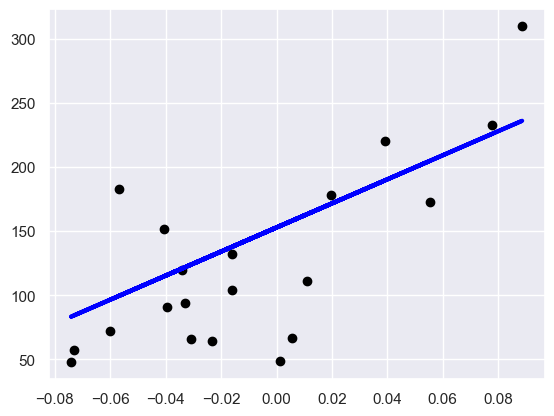

In [1]:
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sns.set_theme()

# Load the diabetes dataset
diabetes_X, diabetes_y = datasets.load_diabetes(return_X_y=True)
# Use only one feature
diabetes_X = diabetes_X[:, np.newaxis, 2]

# Split the data into training/testing sets
diabetes_X_train = diabetes_X[:-20]
diabetes_X_test = diabetes_X[-20:]

# Split the targets into training/testing sets
diabetes_y_train = diabetes_y[:-20]
diabetes_y_test = diabetes_y[-20:]

# Create linear regression object
regr = linear_model.LinearRegression()

# Train the model using the training sets
regr.fit(diabetes_X_train, diabetes_y_train)

# Make predictions using the testing set
diabetes_y_pred = regr.predict(diabetes_X_test)

# The coefficients
print("Coefficients: \n", regr.coef_)
# The mean squared error
print("Mean squared error: %.2f" % mean_squared_error(diabetes_y_test, diabetes_y_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(diabetes_y_test, diabetes_y_pred))

# Plot outputs
plt.scatter(diabetes_X_test, diabetes_y_test, color="black")
plt.plot(diabetes_X_test, diabetes_y_pred, color="blue", linewidth=3)



plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Keras Model Mean squared error: 2878.68
Keras Model Coefficient of determination: 0.46


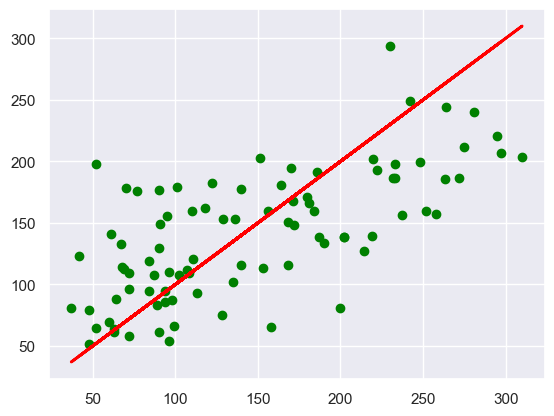

In [9]:
import keras
from sklearn.model_selection import train_test_split

# Load the diabetes dataset
diabetes_X, diabetes_y = datasets.load_diabetes(return_X_y=True)

# Split the data into training/testing sets
diabetes_X_train, diabetes_X_test, diabetes_y_train, diabetes_y_test = \
    train_test_split(diabetes_X, diabetes_y, test_size=0.2, random_state=42)

norm = keras.layers.Normalization(invert=True, axis=0)
norm.adapt(np.atleast_2d(diabetes_y_train))

# Build the model
model = keras.Sequential([
    keras.layers.Dense(1, activation='linear'), norm
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
h = model.fit(diabetes_X_train, diabetes_y_train, epochs=1500, verbose=0)

# Make predictions using the testing set
diabetes_y_pred = model.predict(diabetes_X_test)

# Evaluate the model
mse = mean_squared_error(diabetes_y_test, diabetes_y_pred)
r2 = r2_score(diabetes_y_test, diabetes_y_pred)

print("Keras Model Mean squared error: %.2f" % mse)
print("Keras Model Coefficient of determination: %.2f" % r2)

# Plot outputs
plt.scatter(diabetes_y_test, diabetes_y_pred, color="green")
plt.plot(diabetes_y_test, diabetes_y_test, color="red", linewidth=2)
plt.show()

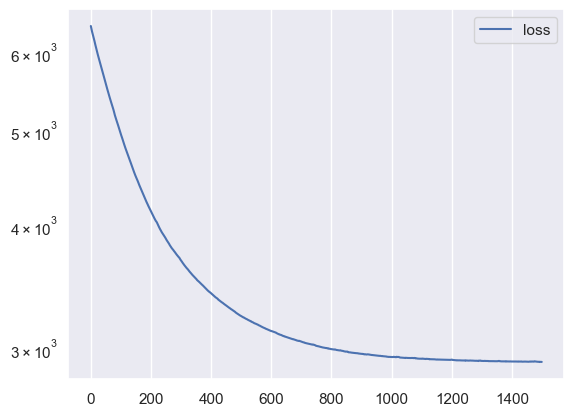

In [10]:
import pandas as pd

# Plot training history
pd.DataFrame(h.history).plot()
plt.yscale('log')

# Czytamy dane z napisow

Poniższy kod wczuje napisy do filmu i wydobywa trzy zmienne:

- `l` - długość napisów znakach
- `t` - cza wyświetlania napisu `[s]'
- `n` - liczba lini w napisie


,czas_start,czas_stop,n,ns,multiline,l,t
index,,,,,,,
1,47.589,51.509,2,2,True,102,3.920
2,51.593,52.719,1,1,False,10,1.126
3,53.511,56.306,1,1,False,11,2.795
4,62.604,66.191,1,1,False,22,3.587
5,77.202,79.412,1,1,False,17,2.210
...,...,...,...,...,...,...,...
568,2532.490,2534.993,1,1,False,39,2.503
569,2537.704,2538.913,1,1,False,14,1.209
570,2653.403,2655.405,1,1,False,25,2.002


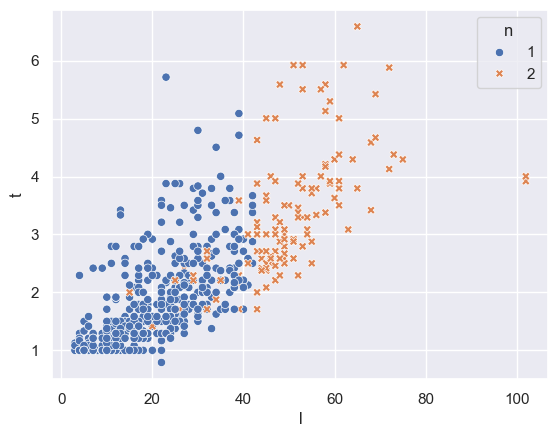

In [3]:
import pandas as pd
import seaborn as sns

df = pd.read_csv("../ex02-regresja_i_klasyfikacja/napisy.csv",index_col=0)
df["n"] = pd.Categorical(df["n"],categories=[1,2])

sns.scatterplot(df, x="l", y="t", style="n", hue="n")
df

## Zadania 2 model czasu

### Polecenie:

Wykonaj regresję w oparciu o dane dotyczące długości napisów filmowych. Waszym zadaniem jest przewidzieć czas trwania wyświetlania napisu (`t`) na podstawie liczby znaków (`l`) i liczby linii w napisie (`n`). Postępujcie według poniższych kroków:

1. **Przewidywanie czasu trwania napisu na podstawie liczby znaków:**
   - Stwórzcie model regresyjny w Keras, który przyjmuje na wejściu liczbę znaków (`l`) i przewiduje czas wyświetlania napisu (`t`).
   - Użyjcie jednej warstwy Dense z odpowiednią funkcją aktywacji.
   - Przetrenujcie model na dostępnych danych.

2. **Rozszerzenie modelu o dodatkową cechę (liczbę linii):**
   - Rozbudujcie poprzedni model, aby na wejściu brał również liczbę linii (`n`) i na tej podstawie przewidywał czas wyświetlania napisu.
   - Połączcie liczbę znaków i liczbę linii jako wejście do modelu, tworząc model wielowymiarowy.
   - Czy użyjcie  więcej warstw Dense zmienia wyniki?
  
### Dodatkowe wskazówki:
- Pamiętajcie o odpowiednim podziale danych na treningowe i testowe.
- Wykorzystajcie optymalizator, np. Adam, oraz funkcję strat, np. `mean_squared_error`.
- Zwizualizujcie wyniki, porównując przewidywane wartości z rzeczywistymi.


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/stepWARNING:tensorflow:6 out of the last 11 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000021B71E8D9E0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Keras Model Mean squared error: 0.61
Keras Model Coefficient of determination: 0.52


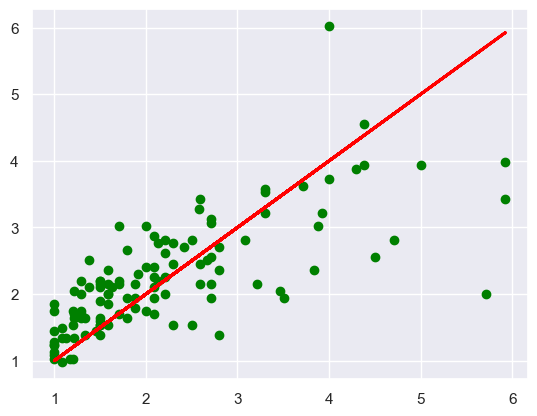

In [ ]:
# 1
import keras
from sklearn.model_selection import train_test_split

# Load the diabetes dataset
X, y = df['l'], df['t']

# Split the data into training/testing sets
X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.2, random_state=42)

norm = keras.layers.Normalization(invert=True, axis=0)
norm.adapt(np.atleast_2d(y_train))

# Build the model
model = keras.Sequential([
    keras.layers.Dense(1, activation='linear'), norm
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
h = model.fit(X_train, y_train, epochs=1500, verbose=0)

# Make predictions using the testing set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Keras Model Mean squared error: %.2f" % mse)
print("Keras Model Coefficient of determination: %.2f" % r2)

# Plot outputs
plt.scatter(y_test, y_pred, color="green")
plt.plot(y_test, y_test, color="red", linewidth=2)
plt.show()

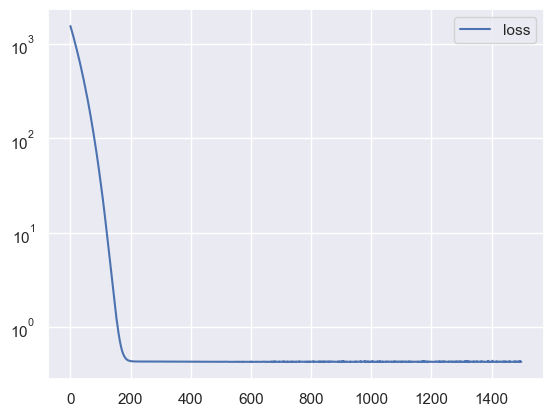

In [12]:
import pandas as pd

# Plot training history
pd.DataFrame(h.history).plot()
plt.yscale('log')

c:\aaasemestr9\myenv\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Keras Model Mean squared error: 0.61
Keras Model Coefficient of determination: 0.52


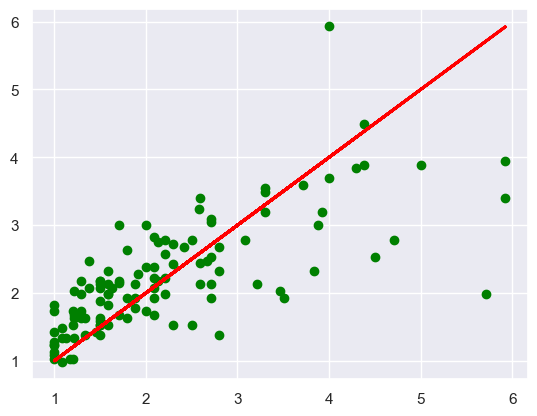

In [14]:
# 2
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the diabetes dataset
l = np.array(df['l'])
y = np.array(df['t'])
n = np.array(df['n'])

X = np.column_stack((l, n))

# Split the data into training/testing sets
X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build the model
model = Sequential()
model.add(Dense(1, input_dim=2, activation='linear'))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
h = model.fit(X_train, y_train, epochs=1500, verbose=0)

# Make predictions using the testing set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Keras Model Mean squared error: %.2f" % mse)
print("Keras Model Coefficient of determination: %.2f" % r2)

# Plot outputs
plt.scatter(y_test, y_pred, color="green")
plt.plot(y_test, y_test, color="red", linewidth=2)
plt.show()

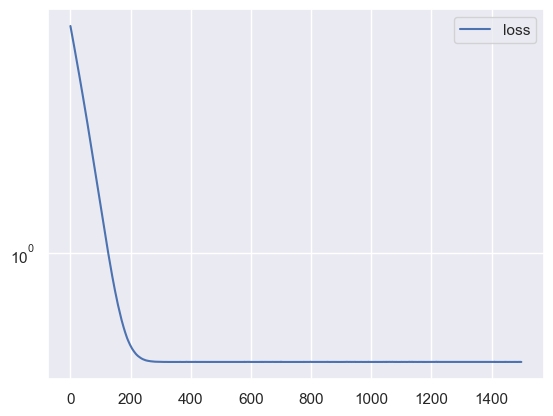

In [15]:
import pandas as pd

# Plot training history
pd.DataFrame(h.history).plot()
plt.yscale('log')

## Zadanie 3 Klasyfikacja 

### Polecenie:

Zadaniem jest zbudowanie modelu klasyfikacyjnego, który będzie przewidywał, czy napis filmowy ma jedną linię, czy więcej, na podstawie dostępnych cech.

1. **Przygotowanie danych:**
   - Skonwertuj liczbę linii (`n`) na zmienną binarną, gdzie `0` oznacza napis z jedną linią, a `1` oznacza napis z więcej niż jedną linią.

2. **Budowa modelu klasyfikacyjnego:**
   - Stwórz model w Keras, który na wejściu przyjmuje cechy, takie jak długość napisu (`l`) oraz czas wyświetlania napisu (`t`).
   - Dodaj warstwę wyjściową z funkcją aktywacji `sigmoid`, aby przewidzieć prawdopodobieństwo klasyfikacji (jedna linia vs więcej niż jedna linia).
   - Użyj odpowiedniej funkcji straty, np. `binary_crossentropy`, oraz optymalizatora, np. Adam.

3. **Trenowanie i ocena modelu:**
   - Podziel dane na zbiór treningowy i testowy.
   - Przetrenuj model i oceń jego skuteczność na danych testowych, korzystając z miary dokładności (accuracy).
   - Przeprowadź analizę wyników, np. poprzez wyświetlenie macierzy pomyłek lub krzywej ROC.
  
### Dodatkowe wskazówki:
- Pamiętaj o normalizacji danych wejściowych, jeśli to konieczne.
- Wyświetl wykresy, które pokazują przebieg trenowania modelu (np. koszt i dokładność).


index
1       True
2      False
3      False
4      False
5      False
       ...  
568    False
569    False
570    False
571     True
572     True
Name: n, Length: 572, dtype: bool

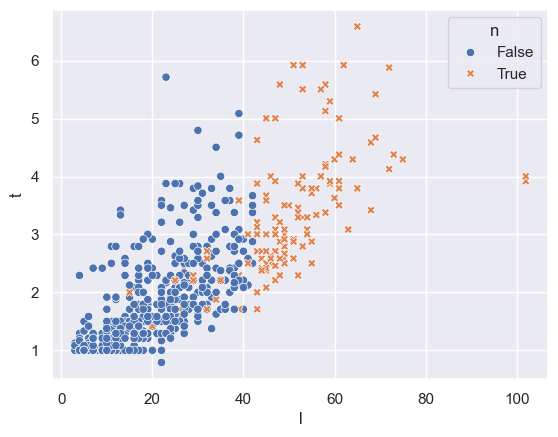

In [ ]:
# 1
import pandas as pd
import seaborn as sns

df = pd.read_csv("../ex02-regresja_i_klasyfikacja/napisy.csv",index_col=0)
df['n'] = df['n'].map({1: False, 2: True})

sns.scatterplot(df, x="l", y="t", style="n", hue="n")

Epoch 1/100


c:\aaasemestr9\myenv\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


103/103 ━━━━━━━━━━━━━━━━━━━━ 54s 10ms/step - accuracy: 0.2968 - loss: 0.8330 - val_accuracy: 0.4565 - val_loss: 0.7699
Epoch 2/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4039 - loss: 0.7347 - val_accuracy: 0.5652 - val_loss: 0.6811
Epoch 3/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6423 - loss: 0.6483 - val_accuracy: 0.8043 - val_loss: 0.6030
Epoch 4/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9100 - loss: 0.5729 - val_accuracy: 0.9565 - val_loss: 0.5351
Epoch 5/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9805 - loss: 0.5076 - val_accuracy: 1.0000 - val_loss: 0.4763
Epoch 6/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9976 - loss: 0.4511 - val_accuracy: 1.0000 - val_loss: 0.4254
Epoch 7/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 0.4025 - val_accuracy: 1.0000 - val_loss: 0.3815
Epoch 8/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 0.3607 - val_accuracy: 1.00

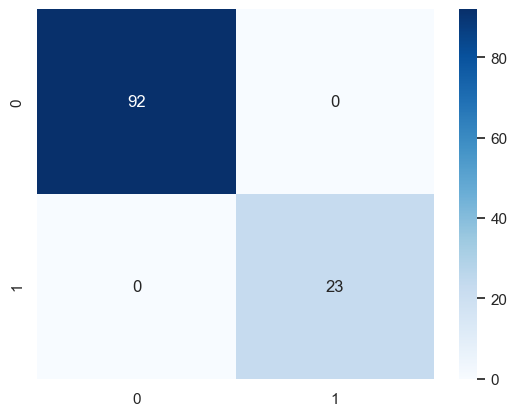

In [21]:
# 2
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

# Load the diabetes dataset
l = np.array(df['l'])
t = np.array(df['t'])
n = np.array(df['n'])

X = np.column_stack((l, n))

# Split the data into training/testing sets
X_train, X_test, n_train, n_test = \
    train_test_split(X, n, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build the model
model = Sequential()
model.add(Dense(1, input_dim=2, activation='sigmoid'))

# Compile the model
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
h = model.fit(X_train, n_train, epochs=100, batch_size=4, validation_split=0.1)

# Make predictions using the testing set
n_pred = model.predict(X_test)
n_pred = (n_pred > 0.5).astype(int).flatten()

# Evaluate the model
loss, accuracy = model.evaluate(X_test, n_test)
print(f"loss: {loss}, accuracy: {accuracy}")

# Plot outputs
cn = confusion_matrix(n_test, n_pred)
sns.heatmap(cn, annot=True, fmt='d', cmap='Blues')
plt.show()